![logo](./figures/LogoLine_horizon_C3S.png)

# Cooling Degree Days

This Jupyter Notebook calculates the index **cd** (cooling_degree_days) for the CMIP6-CMCC_ESM2 model.

For quick demonstration purposes, only one year from the future period (the year 2080) is calculated for a specific region (Spain)

First, the raw CMIP6 model is downloaded from the CDS, then the index is calculated, and the results are compared with the ["Gridded dataset underpinning the Copernicus Interactive Climate Atlas"](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview), also downloaded from the CDS.

### Load Python packages and clone and install the c3s-atlas GitHub repository from the ecmwf-projects

Clone (`git clone`) the [c3s-atlas](https://github.com/ecmwf-projects/c3s-atlas) repository and install it (`pip install -e .`).

Further details on how to clone and install the repository are available in the [requirements](https://github.com/ecmwf-projects/c3s-atlas?tab=readme-ov-file#requirements)

In [1]:
import cdsapi
import os
from pathlib import Path
import xarray as xr
import xclim
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from c3s_atlas.utils import (
    extract_zip_and_delete,
    plot_month
)
from c3s_atlas.fixers import (
    apply_fixers,
    standard_names,
)
from c3s_atlas.indexes import (
    heating_degree_days,
    cooling_degree_days,
)
import c3s_atlas.interpolation as xesmfCICA

### Download climate data with the CDS API
- Catalogue: [CMIP6 climate projections](https://cds.climate.copernicus.eu/datasets/projections-cmip6?tab=overview)

> ⚠️ **Warning: Exposed API Credentials**
>
> For security reasons, it is not recommended to hardcode your Copernicus Climate Data Store (CDS) API credentials — such as `cdsapi_url` and `cdsapi_key` — directly in notebooks.
>
> Instead, it is best to store them securely in a `.cdsapirc` file located in your home directory.
>
> 📄 More info: [CDS API - How to use the API](https://cds.climate.copernicus.eu/how-to-api)

In [1]:
cdsapi_url= "https://cds.climate.copernicus.eu/api"
cdsapi_key= ""

In [7]:
c = cdsapi.Client(url=cdsapi_url, key=cdsapi_key)

Running the code blocks below will download the data from the CDS as specified by the following API keywords:

**Project:** `CMIP6 (Coupled Model Intercomparison Project Phase 6)`\
**Variables:** `Near-Surface Air Temperature; Daily Maximum Near-Surface Air Temperature; Daily Minimum Near-Surface Air Temperature`   
**Temporal Resolution:** `Daily`  
**Model:** `CMCC-ESM2`  
**Experiment:** `SSP5-8.5`  
**Year:** `2080`  
**Month:** `All`  
**Day:** `All`  

In [8]:
# define some global attributes for the CDS-API
CMIP6_years = {
    "ssp5_8_5": ["2080"],
}
# variables
variables = {
    't': 'near_surface_air_temperature', 
    'tx': 'daily_maximum_near_surface_air_temperature',
    'tn': 'daily_minimum_near_surface_air_temperature'
}
# directory to download the files
file_dest_CMIP6 = Path('./data/CMIP6')

In [9]:
months = [
    '01', '02', '03',
    '04', '05', '06',
    '07', '08', '09',
    '10', '11', '12'
]
        
days = [
    '01', '02', '03',
    '04', '05', '06',
    '07', '08', '09',
    '10', '11', '12',
    '13', '14', '15',
    '16', '17', '18',
    '19', '20', '21',
    '22', '23', '24',
    '25', '26', '27',
    '28', '29', '30', '31'
]

In [ ]:
os.makedirs(file_dest_CMIP6, exist_ok=True)

for experiment in CMIP6_years.keys():
    for year in CMIP6_years[experiment]:
        for var in variables.keys():
            path_zip = file_dest_CMIP6 / f"CMIP6_{var}_{experiment}_{year}.zip"
            c.retrieve(
                'projections-cmip6',
                {
                    'format': 'zip',
                    'temporal_resolution': 'daily',
                    'variable': variables[var],
                    'experiment': experiment,
                    'model': 'cmcc_esm2',
                    'year': year,
                    'month': months,
                    'day': days,
                },
                path_zip)
            # Extract zip file into the specified directory and remove zip
            extract_zip_and_delete(path_zip) 

### Load files with xarray

- https://docs.xarray.dev/en/stable/

In [12]:
# load files
ds_t = xr.open_dataset(file_dest_CMIP6 / "CMIP6_t_ssp5_8_5_2080.nc")
ds_tx = xr.open_dataset(file_dest_CMIP6 / "CMIP6_tx_ssp5_8_5_2080.nc")
ds_tn = xr.open_dataset(file_dest_CMIP6 / "CMIP6_tn_ssp5_8_5_2080.nc")

### Homogenization

Once the data is downloaded from the CDS it undergoes a process of homogenization (see the ["Homogenization"](https://github.com/ecmwf-projects/c3s-atlas/blob/main/c3s_atlas/README.md) section for more details). 

- `dataset_variable`: Renames the variable using, respectively, the original (raw) variable name and the corresponding C3S Atlas variable name provided as inputs.
- `aggregation`: Specifies the aggregation function applied to resample the data to either monthly or daily temporal resolution.

In [13]:
project_id = "CMIP6"
variable = 'tas'
var_mapping = {
            "dataset_variable": {"tas": "data"},
            "aggregation": {"data": "mean"},
        }
ds_t = apply_fixers(ds_t, variable, project_id, var_mapping)

2026-02-20 10:27:03,368 — Homogenization-fixers — INFO — Dataset has already the correct names for its coordinates
2026-02-20 10:27:03,383 — Homogenization-fixers — INFO — Fixing calendar for <xarray.Dataset> Size: 81MB
Dimensions:    (time: 365, bnds: 2, lat: 192, lon: 288)
Coordinates:
  * time       (time) object 3kB 2080-01-01 12:00:00 ... 2080-12-31 12:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 6kB ...
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 5kB ...
    tas        (time, lat, lon) float32 81MB ...
Attributes: (12/48)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   60225.0
    branch_time_in_parent:  60225.0


In [14]:
project_id = "CMIP6"
variable = 'tasmax'
var_mapping = {
            "dataset_variable": {"tasmax": "data"},
            "aggregation": {"data": "mean"},
        }
ds_tx = apply_fixers(ds_tx, variable, project_id, var_mapping)

2026-02-20 10:27:05,233 — Homogenization-fixers — INFO — Dataset has already the correct names for its coordinates
2026-02-20 10:27:05,241 — Homogenization-fixers — INFO — Fixing calendar for <xarray.Dataset> Size: 81MB
Dimensions:    (time: 365, bnds: 2, lat: 192, lon: 288)
Coordinates:
  * time       (time) object 3kB 2080-01-01 12:00:00 ... 2080-12-31 12:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 6kB ...
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 5kB ...
    tasmax     (time, lat, lon) float32 81MB ...
Attributes: (12/48)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   60225.0
    branch_time_in_parent:  60225.0


In [15]:
project_id = "CMIP6"
variable = 'tasmin'
var_mapping = {
            "dataset_variable": {"tasmin": "data"},
            "aggregation": {"data": "mean"},
        }
ds_tn = apply_fixers(ds_tn, variable, project_id, var_mapping)

2026-02-20 10:27:08,859 — Homogenization-fixers — INFO — Dataset has already the correct names for its coordinates
2026-02-20 10:27:08,864 — Homogenization-fixers — INFO — Fixing calendar for <xarray.Dataset> Size: 81MB
Dimensions:    (time: 365, bnds: 2, lat: 192, lon: 288)
Coordinates:
  * time       (time) object 3kB 2080-01-01 12:00:00 ... 2080-12-31 12:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 6kB ...
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 5kB ...
    tasmin     (time, lat, lon) float32 81MB ...
Attributes: (12/48)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   60225.0
    branch_time_in_parent:  60225.0


### Calculate cd using in-house functions indexes. 
Some indices are not implemented in open-source Python libraries or require custom ([in-house](https://github.com/ecmwf-projects/c3s-atlas/tree/main/c3s_atlas#c3s_atlasin-house-python-functions)) implementations to enhance operability for large-scale index calculations. **cooling_degree_days** in-house functions resample the index to annual resolutions using the argument ('YS'). See [pandas timeseries](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#dateoffset-objects) for more temporal resampling options.

In [16]:
ds_cd = cooling_degree_days(tas = ds_t['tas'], 
                            tasmax = ds_tx['tasmax'], 
                            tasmin = ds_tn['tasmin'],
                            freq = 'YS',
                            thresh = 22)

"freq" attribute indicates output time frequency following [pandas timeserie codes](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#dateoffset-objects)

In [17]:
# Convert DataArray to Dataset with specified variable name
ds_cd = ds_cd.to_dataset(name='cd')
ds_cd = standard_names(ds_cd)

### Interpolation to a common and regular grid using xESMF
A wrapper for the [xESMF](https://xesmf.readthedocs.io/en/stable/) Python package was developed within the framework of the C3S Atlas project to extend its functionalities to all datasets (regular, curvilinear, etc.)

In [18]:
# interpolate data
int_attr = {'interpolation_method' : 'conservative_normed', 
            'lats' : np.arange(-89.5, 90.5, 1),
            'lons' : np.arange(-179.5, 180.5, 1),
            'var_name' : 'cd'
}

In [19]:
INTER = xesmfCICA.Interpolator(int_attr)

In [ ]:
ds_cd_i = INTER(ds_cd)

### Compare the results with the "Gridded dataset underpinning the Copernicus Interactive Climate Atlas"
- Catalogue: [Gridded dataset underpinning the Copernicus Interactive Climate Atlas](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview)

Running the code blocks below will download the data from the CDS as specified by the following API keywords:

**Project:** `C3S Atlas dataset`\
**Origin:** `CMIP6`\
**Variables:** `Annual Cooling Degree Days`  
**Experiment:** `SSP5-8.5`  
**Year:** `2015-2100`  
**Month:** `All`  
**Day:** `All`  
**Area:** `[45.5, 5.5, 34, −11.5]` (Cropped over Spain)

In [21]:
project = "CMIP6"
scenario = "ss585"
var = 'cd'
# directory to download the files
dest = Path('./data/CMIP6')
os.makedirs(dest, exist_ok=True)

##### Download SSP scenario

In [ ]:
filename = 'cd_CMIP6_ss585_yr_201501-210012.zip'
dataset = "multi-origin-c3s-atlas"
request = {
    'origin': 'cmip6',
    'experiment': 'ssp5_8_5',
    'domain': 'global',
    'variable': 'annual_cooling_degree_days',
    'area': [44.5, -9.5, 35.5, 3.5]
}

c.retrieve(dataset, request).download(dest / filename)
extract_zip_and_delete(dest / filename) 

In [23]:
# load data with xarray
ds_cd_C3S_Atlas = xr.open_dataset(dest /"cd_CMIP6_ss585_yr_201501-210012.nc")

In [24]:
# select member (note than member names in the "Copernicus Interactive Climate Atlas: gridded monthly dataset" 
# are remappend to follow the DRS as much as possible)
select_member = [
    str(mem.data) for mem in ds_cd_C3S_Atlas.member_id if "cmcc-esm2" in str(mem.data).lower()
][0]
print(select_member)

CMCC_CMCC-ESM2_r1i1p1f1


In [25]:
ds_cd_C3S_Atlas_member_year = ds_cd_C3S_Atlas.sel(
    member = np.where(ds_cd_C3S_Atlas.member_id == select_member)[0], 
    time = "2080"
)

#### Plot results
Comparison of the results obtained with present Jupyter notebook and the reference [C3S Atlas Dataset](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview) underpinning the C3S Atlas. A geographical subset focusing on Spain is selected to show the results.

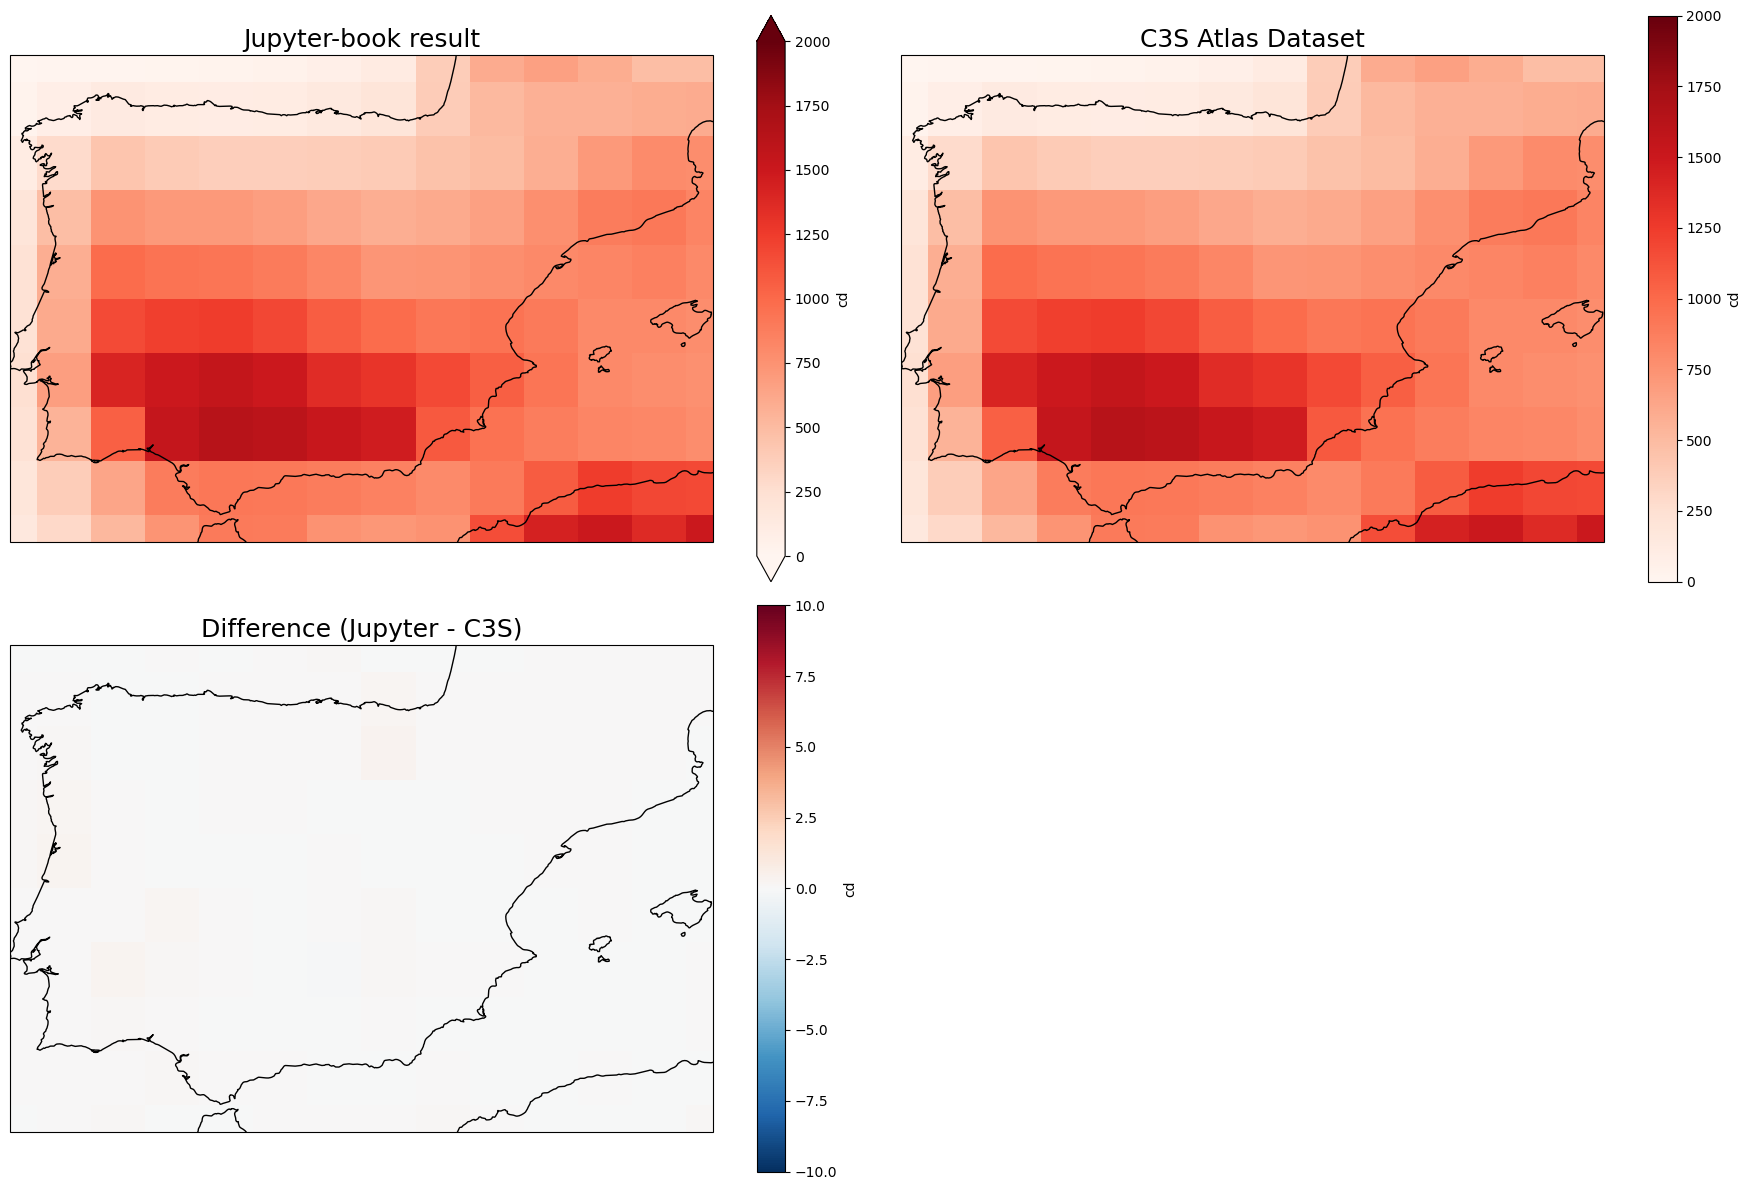

In [31]:
zoomin_extent = [-9.5, 3.5, 35.5, 44.5]
title_size = 18

proj = ccrs.PlateCarree()
fig, ax = plt.subplots(
    nrows=2, ncols=2,
    subplot_kw={'projection': proj},
    figsize=(18, 12)
)

# calculate climatologies and the difference
cd_i_mean = ds_cd_i["cd"].mean(dim="time")
cd_c3s_mean = ds_cd_C3S_Atlas_member_year["cd"].mean(dim="time")
diff = cd_i_mean - cd_c3s_mean

cd_i_mean.plot(ax=ax[0, 0], cmap="Reds", vmin=0, vmax=2000)
ax[0, 0].set_title("Jupyter-book result", fontsize = title_size)
ax[0, 0].set_extent(zoomin_extent)
ax[0, 0].coastlines()

cd_c3s_mean.plot(ax=ax[0, 1], cmap="Reds", vmin=0, vmax=2000)
ax[0, 1].set_title("C3S Atlas Dataset", fontsize = title_size)
ax[0, 1].set_extent(zoomin_extent)
ax[0, 1].coastlines()

diff.plot(ax=ax[1, 0], cmap="RdBu_r", vmin=-10, vmax=10)
ax[1, 0].set_title("Difference (Jupyter - C3S)", fontsize = title_size)
ax[1, 0].set_extent(zoomin_extent)
ax[1, 0].coastlines()

fig.delaxes(ax[1, 1])
plt.tight_layout()
plt.show()

The figure demonstrates that the results obtained with this notebook are identical to those from the C3S Atlas datasets, and are therefore fully reproducible.